# Period estimation statistics

In [1]:
import requests
import time
import io
import os

import numpy as np
import pandas as pd

import rocks

from figure_mask import compute_mask, print_statistics

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("poster")

### Combination BFT & SSOFT

In [2]:
cols = [
    'sso_number', 'sso_name', 'sso_class',
    'spins.1.period.value', 'spins.2.period.value',
    'spins.1.period.error.min',
    'spins.1.period.error.max',
    'spins.1.period_type',
    'spins.1.period_flag',
    'spins.1.technique'
]

# Read BFT with rocks
bft = rocks.load_bft(columns=cols)

In [3]:
# bft[bft["spins.1.period.value"] == bft["spins.1.period.value"]].groupby("spins.1.period_flag").count()

In [4]:
print("{:,} periods available in the BFT".format(len(bft[bft["spins.1.period.value"] == bft["spins.1.period.value"]])))

47,064 periods available in the BFT


In [5]:
# You need SSOFT version 2024.09
# see fink_spins/generate_data.py
data_fink = "../../"
ssoft = pd.read_parquet(os.path.join(data_fink, "data", "ztf", "sso_ZTF.parquet"))

In [6]:
flavor = "SSHG1G2"

## Comparison to literature

In [7]:
# Keep only known periods 1 in the BFT
data = ssoft.merge(bft, left_on="name", right_on="sso_name", how="left")
data = data[data["spins.1.period.value"] == data["spins.1.period.value"]]

# sort by number of observations
data = data.sort_values("n_obs", ascending=False)
# data = data.sort_values(f'{flavor}_rms', ascending=False)

col_display = ["sso_number", "sso_name", "n_obs", "sso_class", "spins.1.period.value", "spins.2.period.value", f"{flavor}_period", 'spins.1.technique']
col_display = ["sso_number", "sso_name", "n_obs", "sso_class", "spins.1.period.value", f"{flavor}_period", 'spins.1.technique', f'{flavor}_rms']

if flavor == 'SHG1G2':
    col_display.append(f"{flavor}_R")

cond = data.sso_class.str.contains("Inner")
cond = (data['spins.1.technique']=='LCI') & ( np.abs(data['spins.1.period.value']-data['SSHG1G2_period']) < 0.1)

data.loc[cond,col_display].head(50)

,sso_number,sso_name,n_obs,sso_class,spins.1.period.value,SSHG1G2_period,spins.1.technique,SSHG1G2_rms
137853,22149,2000 WD49,517.0,Trojan>L4,6.751700,6.751807,LCI,0.054182
84369,4209,Briggs,508.0,MB>Outer,12.252700,12.254683,LCI,0.114755
33629,1437,Diomedes,490.0,Trojan>L4,24.498000,24.424891,LCI,0.124760
119466,19844,2000 ST317,475.0,Trojan>L5,14.542000,14.530661,LCI,0.089067
53577,5209,Oloosson,462.0,Trojan>L4,11.602700,11.604522,LCI,0.147398
115169,761,Brendelia,453.0,MB>Outer,57.995000,57.941544,LCI,0.060714
25118,265,Anna,435.0,Phocaea,11.690300,11.692166,LCI,0.177643
4640,2456,Palamedes,430.0,Trojan>L4,7.252200,7.259254,LCI,0.075203
48154,2528,Mohler,426.0,MB>Outer,6.491300,6.488413,LCI,0.308926
136430,1828,Kashirina,421.0,MB>Outer,14.865200,14.855475,LCI,0.109088


In [8]:
print("{:,} periods available in the BFT x Fink".format(len(data[data["spins.1.period.value"] == data["spins.1.period.value"]])))

34,302 periods available in the BFT x Fink


### Mask

It is not obvious yet what are the criteria for good period estimation, so let's stick with masks defined for sHG1G2

In [9]:
maskFINK_inter = compute_mask(ssoft, thres_spin=1e-3, thres_phase=1e-3, R_min=0.30, model='FINK', kind='inter')
maskFINK_union = compute_mask(ssoft, thres_spin=1e-3, thres_phase=1e-3, R_min=0.30, model='FINK', kind='union')

for model in ['HG', 'HG1G2', 'SHG1G2', 'FINK']:
    print_statistics(ssoft, model)
    print()

mask = maskFINK_union
print(sum(mask))

  All data       : 140559  (100.00%)
  Mask HG (g∩r) : 137746  ( 98.00%)
  Mask HG (gUr) : 137752  ( 98.00%)

  All data       : 140559  (100.00%)
  Mask HG1G2 (g∩r) :  57578  ( 40.96%)
  Mask HG1G2 (gUr) : 101207  ( 72.00%)

  All data       : 140559  (100.00%)
  Mask SHG1G2 (g∩r) :  76798  ( 54.64%)
  Mask SHG1G2 (gUr) : 114519  ( 81.47%)

  All data       : 140559  (100.00%)
  Mask FINK (g∩r) :  57394  ( 40.83%)
  Mask FINK (gUr) :  95268  ( 67.78%)

95268


In [10]:
print("{:,} periods available in the MASK(BFT x Fink)".format(
    len(data[data["spins.1.period.value"] == data["spins.1.period.value"]][mask])))

23,713 periods available in the MASK(BFT x Fink)


/tmp/ipykernel_693613/3784457356.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  len(data[data["spins.1.period.value"] == data["spins.1.period.value"]][mask])))


### Period distribution

/tmp/ipykernel_693613/2063270170.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data[mask]["spins.1.period.value"],
/tmp/ipykernel_693613/2063270170.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data[mask][f"{flavor}_period"],


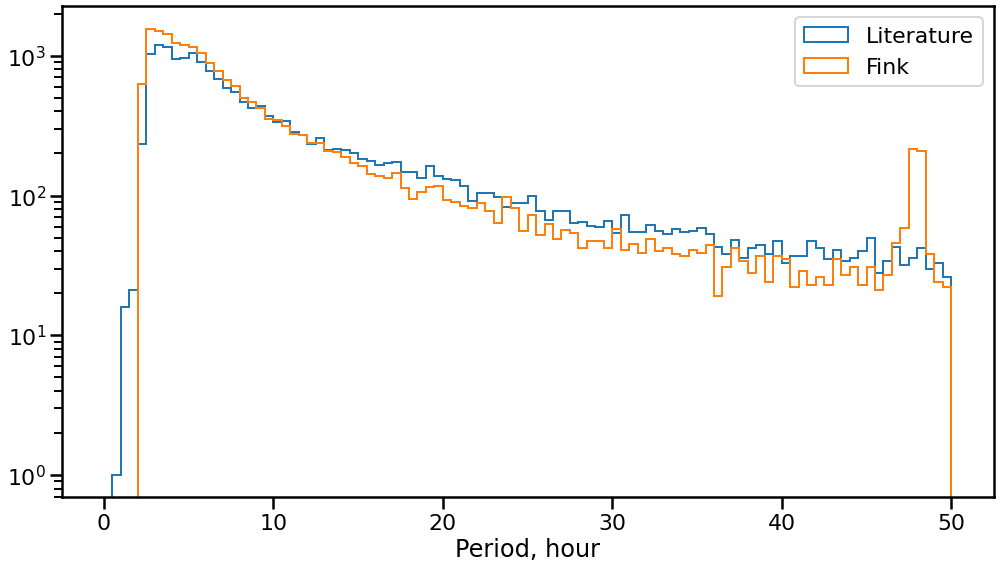

In [11]:
fig = plt.figure(figsize=(14, 8))

xmax = 50

_, bins, _ = plt.hist(
    data[mask]["spins.1.period.value"], 
    density=False, 
    bins=100, 
    range=(0, xmax), 
    histtype="step",
    label="Literature"
)
plt.hist(
    data[mask][f"{flavor}_period"], 
    density=False, 
    bins=bins, 
    range=(0, xmax), 
    histtype="step",
    label="Fink"
)
plt.legend()
plt.yscale("log")
plt.xlabel("Period, hour")
plt.tight_layout()

General trend is OK. Fink has more small periods than in the literature (few hours). A large bump at `P=24h` which is not-so-suprising given the general cadence of ZTF...

## 24 hours bump

This seems clearly an artifact from the cadence. Let's try to correlate this bump with other parameters:

/tmp/ipykernel_693613/1000316206.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(data[mask]["SSHG1G2_period"], data[mask][val], alpha=0.1, s=20)
/tmp/ipykernel_693613/1000316206.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(data[mask]["SSHG1G2_period"], data[mask][val], alpha=0.1, s=20)


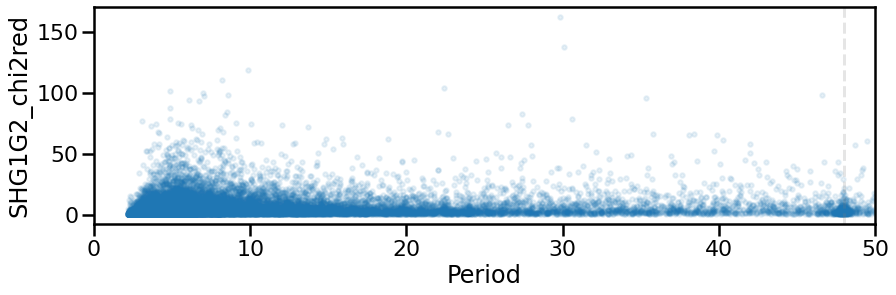

/tmp/ipykernel_693613/1000316206.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(data[mask]["SSHG1G2_period"], data[mask][val], alpha=0.1, s=20)
/tmp/ipykernel_693613/1000316206.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(data[mask]["SSHG1G2_period"], data[mask][val], alpha=0.1, s=20)


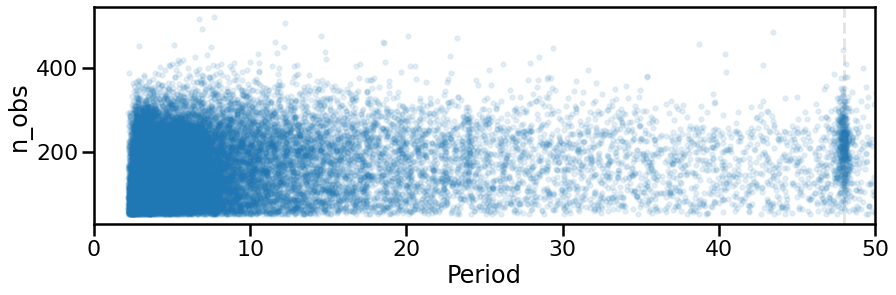

/tmp/ipykernel_693613/1000316206.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(data[mask]["SSHG1G2_period"], data[mask][val], alpha=0.1, s=20)
/tmp/ipykernel_693613/1000316206.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(data[mask]["SSHG1G2_period"], data[mask][val], alpha=0.1, s=20)


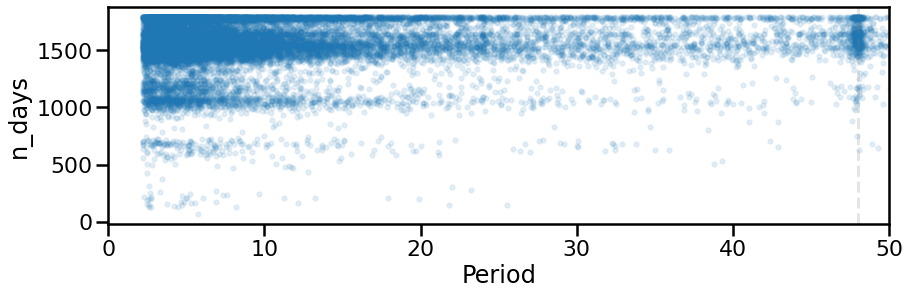

/tmp/ipykernel_693613/1000316206.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(data[mask]["SSHG1G2_period"], data[mask][val], alpha=0.1, s=20)
/tmp/ipykernel_693613/1000316206.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(data[mask]["SSHG1G2_period"], data[mask][val], alpha=0.1, s=20)


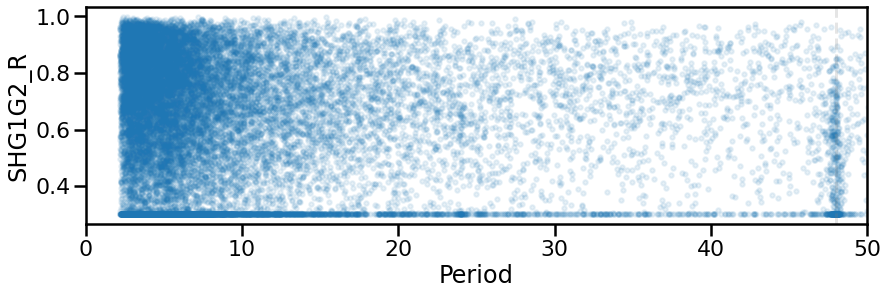

/tmp/ipykernel_693613/1000316206.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(data[mask]["SSHG1G2_period"], data[mask][val], alpha=0.1, s=20)
/tmp/ipykernel_693613/1000316206.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(data[mask]["SSHG1G2_period"], data[mask][val], alpha=0.1, s=20)


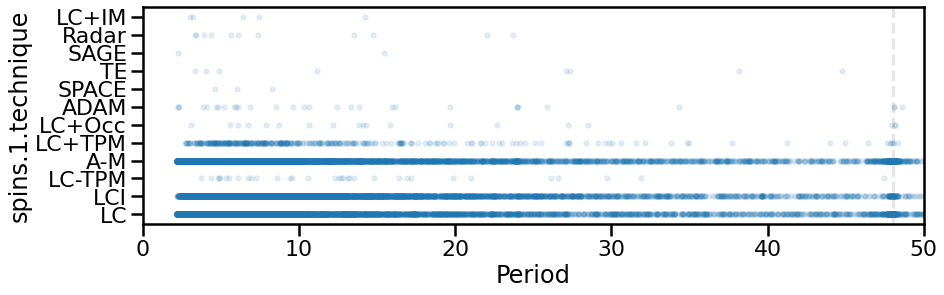

In [12]:
vals = ["SHG1G2_chi2red", "n_obs", "n_days", "SHG1G2_R", "spins.1.technique"]

for val in vals:
    fig = plt.figure(figsize=(14, 4))

    plt.scatter(data[mask]["SSHG1G2_period"], data[mask][val], alpha=0.1, s=20)
    plt.axvline(48, ls='--', color='grey', alpha=0.2)
    plt.ylabel(val)
    plt.xlabel("Period")
    plt.xlim(0, 50)
    plt.show()

Nothing really correlated. We should probe the lightcurve morphology (number of opposition, real cadence, ...)

## Scatter plot

Let's compare directly periods:

In [13]:
def alias_func(x, i, j, p_feat):
    """ Return aliases relation

    x: float
        Fink period
    i: int
        Strictly positive integer. Mode.
    j: int
        Alias
    p_feat: float
        Frequency of a feature
    """
    return (i + 1) * p_feat * x / np.abs(p_feat - j *x)

/tmp/ipykernel_693613/3371567779.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data[mask][f"{flavor}_period"],
/tmp/ipykernel_693613/3371567779.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data[mask]["spins.1.period.value"],
/tmp/ipykernel_693613/3371567779.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data[mask][f"{flavor}_period"],
/tmp/ipykernel_693613/3371567779.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data[mask]["spins.1.period.value"],
/tmp/ipykernel_693613/1958375727.py:13: RuntimeWarning: divide by zero encountered in divide
  return (i + 1) * p_feat * x / np.abs(p_feat - j *x)


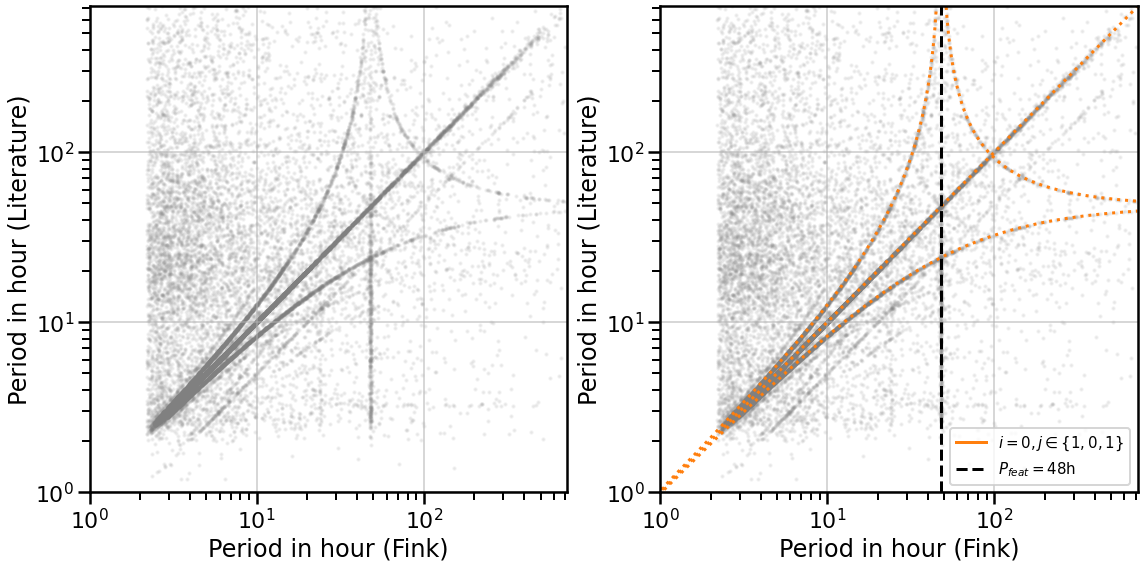

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

maxval = 30*24

for ax in axes:
    ax.scatter(
        data[mask][f"{flavor}_period"],
        data[mask]["spins.1.period.value"], 
        marker='.', alpha=0.1, s=20, color='grey'
    )
    # plt.colorbar()
    ax.grid(alpha=0.5)
    ax.set_xlim(1, maxval)
    ax.set_ylim(1, maxval)
    ax.set_xlabel("Period in hour (Fink)")
    ax.set_ylabel("Period in hour (Literature)")
    ax.set_xscale("log")
    ax.set_yscale("log")

xr = np.array(range(maxval))

axes[1].plot(0.1, 0.1, color="C1", label=r"$i=0, j \in \{1, 0, 1 \}$") # For the legend
# axes[1].plot(0.1, 0.1, color="C2", label=r"$i=1, j \in \{-2, 1, 0, 1, 2 \}$") # For the legend

for i in [0]:
    for j in range(-1, 2):
        axes[1].plot(xr, alias_func(xr, i, j, p_feat=48), color='C{}'.format(i+1), ls=':', label="")
axes[1].axvline(48, ls='--', color='black', label=r"$P_{feat} = 48$h")
# axes[1].axvline(24, ls=':', color='black', label=r"$P_{feat} = 24$h")

axes[1].legend(prop={'size': 15})
plt.tight_layout()

The left plot shows strong features that are actually related to aliases of the fundamental and harmonics of the true period. They are easily parametrized using:

$$
\dfrac{1}{P_{Fink}} = \Big | \dfrac{i + 1}{P_{true}} + \dfrac{j}{P_{feat}} \Big |
$$

or

$$
P_{i, j} = \dfrac{(i + 1)\times P_{feat} \times P_{Fink}}{|P_{feat} - j \times P_{Fink}|}
$$

where $P_{feat}$ is the period of an instrumental effect rooted in the structure of the window function of the signal (e.g. the cadence), $P_{Fink}$ is the best fit period from Fink data, $i$ is a positive integer related to harmonics, and $j$ is an integer related to aliases of the fundamental ($i=0$) and its harmonics ($i>0$). In the plot above the case for $P_{feat} = 48h$, $i \in \{0, 1\}$ and $j \in \{-2, 1, 0, 1, 2\}$ is shown. Some interesting cases clearly seen on the plot:
- $i=0, j=0$: fundamental
- $i=1, j=0$: first harmonics
- $i=1, j=\pm 1$: aliases of the first harmonics

In [15]:
data[mask][np.isclose(data[mask][f"{flavor}_period"], data[mask]["spins.1.period.value"], 1e-1)]

/tmp/ipykernel_693613/516617632.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data[mask][np.isclose(data[mask][f"{flavor}_period"], data[mask]["spins.1.period.value"], 1e-1)]
/tmp/ipykernel_693613/516617632.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data[mask][np.isclose(data[mask][f"{flavor}_period"], data[mask]["spins.1.period.value"], 1e-1)]
/tmp/ipykernel_693613/516617632.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data[mask][np.isclose(data[mask][f"{flavor}_period"], data[mask]["spins.1.period.value"], 1e-1)]


,ssnamenr,HG_chi2red,HG_status,HG_fit,HG_rms,HG_rms_g,HG_rms_r,HG_median_error_phot,HG_median_error_phot_1,HG_median_error_phot_2,...,sso_number,sso_name,sso_class,spins.1.period.value,spins.2.period.value,spins.1.period.error.min,spins.1.period.error.max,spins.1.period_type,spins.1.period_flag,spins.1.technique
137853,22149,5.992198,2.0,0.0,0.137289,0.142524,0.134073,0.065484,0.070952,0.060745,...,22149,2000 WD49,Trojan>L4,6.751700,NaN,-0.000100,0.000100,sidereal,None,LCI
84369,4209,19.879328,2.0,0.0,0.185987,0.183811,0.187140,0.044664,0.044515,0.044862,...,4209,Briggs,MB>Outer,12.252700,12.25270,-0.000200,0.000200,Sidereal,None,LCI
86588,624,102.214050,2.0,0.0,0.259976,0.208263,0.288384,0.028400,0.029661,0.027315,...,624,Hektor,Trojan>L4,6.920509,6.92051,-0.000005,0.000005,Sidereal,Quality of the period not rated.,LC-TPM
13688,2363,13.863765,2.0,0.0,0.135386,0.136552,0.134443,0.037333,0.039404,0.036010,...,2363,Cebriones,Trojan>L5,20.076400,NaN,-1.000000,1.000000,sidereal,None,LC
119466,19844,4.997290,2.0,0.0,0.170983,0.175260,0.168345,0.083725,0.090713,0.079419,...,19844,2000 ST317,Trojan>L5,14.542000,NaN,-0.001000,0.001000,sidereal,None,LCI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30627,76298,5.347901,2.0,0.0,0.262481,0.205102,0.302904,0.142699,0.155125,0.136684,...,76298,2000 EC131,MB>Outer,23.376500,NaN,NaN,NaN,synodic,None,LC
73682,169182,3.039320,2.0,0.0,0.133159,0.131904,0.133922,0.086160,0.096324,0.080907,...,169182,2001 QJ283,MB>Outer,4.826770,NaN,NaN,NaN,Synodic,None,LC
27001,115409,1.856445,2.0,0.0,0.141938,0.141576,0.142141,0.123212,0.128333,0.123212,...,115409,2003 SW294,MB>Inner,7.473000,NaN,-0.015300,0.015300,Synodic,U=2,LC
3044,119502,3.593955,2.0,0.0,0.231812,0.235492,0.228879,0.146002,0.160601,0.134118,...,119502,2001 UH120,MB>Middle,6.650000,NaN,-0.003600,0.003600,Synodic,U=2,LC


### More reliable flags

In [16]:
# Choosing only reliable flags
mask_pure = data["spins.1.period_flag"].isin(["U=1", "U=2", "U=3", "U=1+", "U=2+", "U=3+", "U=1-", "U=2-", "U=3-"])

In [17]:
mask_pure

36546     False
137853    False
30050     False
84369     False
27117     False
          ...  
139873    False
140046    False
140124     True
140326    False
140359    False
Name: spins.1.period_flag, Length: 34302, dtype: bool

/tmp/ipykernel_693613/1958375727.py:13: RuntimeWarning: divide by zero encountered in divide
  return (i + 1) * p_feat * x / np.abs(p_feat - j *x)


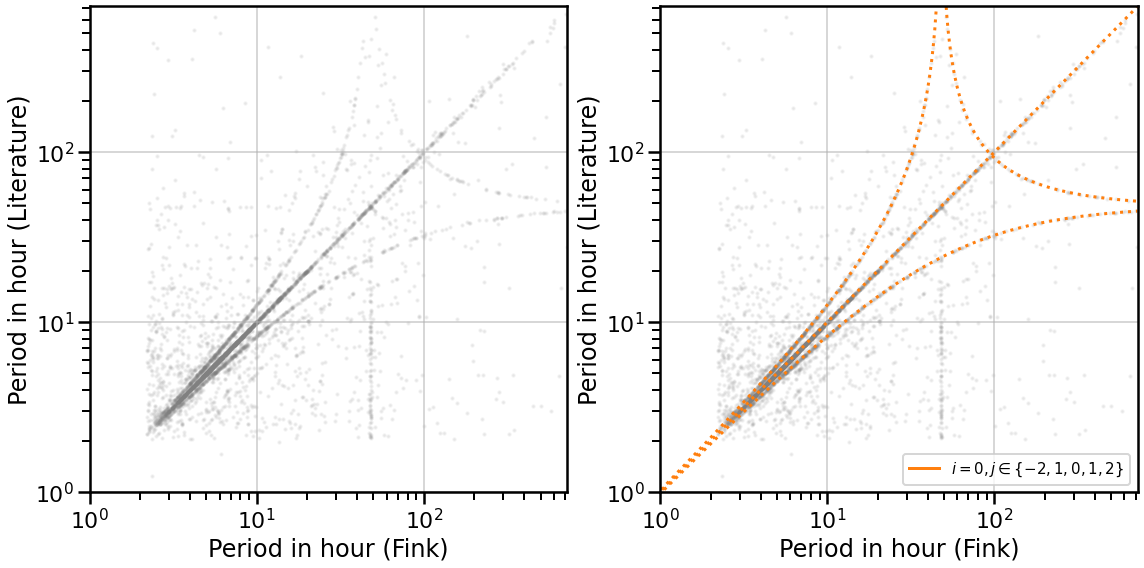

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

maxval = 30*24

for ax in axes:
    ax.scatter(
        data[mask_pure][f"{flavor}_period"], 
        data[mask_pure]["spins.1.period.value"], 
        marker='.', alpha=0.1, s=20, color='grey'
    )
    # plt.colorbar()
    ax.grid(alpha=0.5)
    ax.set_xlim(1, maxval)
    ax.set_ylim(1, maxval)
    ax.set_xlabel("Period in hour (Fink)")
    ax.set_ylabel("Period in hour (Literature)")
    ax.set_xscale("log")
    ax.set_yscale("log")

xr = np.array(range(maxval))

axes[1].plot(0.1, 0.1, color="C1", label=r"$i=0, j \in \{-2, 1, 0, 1, 2 \}$") # For the legend
# axes[1].plot(0.1, 0.1, color="C2", label=r"$i=1, j \in \{-2, 1, 0, 1, 2 \}$") # For the legend

for i in [0]:
    for j in range(-1, 2):
        axes[1].plot(xr, alias_func(xr, i, j, p_feat=48), color='C{}'.format(i+1), ls=':', label="")
# axes[1].axvline(24, ls=':', color='black', label=r"$P_{feat} = 48$h")

axes[1].legend(prop={'size': 15})
plt.tight_layout()

## Aliases vs mismatches

Let's count how many Fink period are just harmonics or aliases of the literature periods, and how many are mismatching:

In [19]:
from collections import Counter

def is_alias(obs, true, p_feat):
    for i in [0, 1]:
        for j in range(-2, 3):
            tmp = alias_func(obs, i, j, p_feat)
            if np.isclose(tmp, true, 1e-1):
                return "{},{}".format(i, j)
    return ""

def is_feature(obs, p_feat):
    if np.isclose(obs, p_feat, 1e-1):
        return True
    return False

In [20]:
tmp = [is_alias(obs, true, p_feat=48) for obs, true in zip(data[mask][f"{flavor}_period"], data[mask]["spins.1.period.value"])]
d = Counter(tmp)

/tmp/ipykernel_693613/2765036623.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  tmp = [is_alias(obs, true, p_feat=48) for obs, true in zip(data[mask][f"{flavor}_period"], data[mask]["spins.1.period.value"])]
/tmp/ipykernel_693613/2765036623.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  tmp = [is_alias(obs, true, p_feat=48) for obs, true in zip(data[mask][f"{flavor}_period"], data[mask]["spins.1.period.value"])]


In [21]:
matches = np.sum([d[i] for i in d if i != ""])
nfeat = np.sum([is_feature(f, 48.) for f in data[mask][f"{flavor}_period"]])

msg = "{:.2f}% are matches (true, harmonics or aliases), {:.2f}% are cadence frequency (24h period), and {:.2f}% have no match.".format(
    matches/len(tmp)*100, nfeat/len(tmp)*100, 100 - (matches + nfeat)/len(tmp)*100)
print(msg)

/tmp/ipykernel_693613/1118929929.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  nfeat = np.sum([is_feature(f, 48.) for f in data[mask][f"{flavor}_period"]])


72.81% are matches (true, harmonics or aliases), 3.91% are cadence frequency (24h period), and 23.28% have no match.


In [22]:
true = np.sum([d[i] for i in d if i == "0,0"])
true_alias = np.sum([d[i] for i in d if i in ["0,-2", "0,-1", "0,1", "0,2"]])
first_harmonics = np.sum([d[i] for i in d if i == "1,0"])
first_harmonics_alias = np.sum([d[i] for i in d if i in ["1,-2", "1,-1", "1,1", "1,2"]])

In [23]:
msg = """
{} are exact matches (0, 0)
{} are aliases of the true frequency (0, j)
{} are the first harmonics (1, 0)
{} are aliases of the first harmonics (1, j)
{} are 48h period
""".format(true, true_alias, first_harmonics, first_harmonics_alias, nfeat)
print(msg)


7775 are exact matches (0, 0)
8406 are aliases of the true frequency (0, j)
185 are the first harmonics (1, 0)
900 are aliases of the first harmonics (1, j)
926 are 48h period



So in the end we have a strong contamination from the daily cadence of the survey. But on overall, that's 72% of the frequencies that are related to the values reported in the literature. This is a first good results as, assuming the literature is correct, we expect about the same amount of correctness in the whole Fink sample.

Note that in this first trial, the best fit period from Fink was selected as the highest peak in the periodogram. This is known to produce these artifacts. We will now move to a more robust method.